Frist step is to find the root DIR and print out the shape of the data.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# -----------------------------
# 1) find repo root
# -----------------------------
NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start_path: Path):
    cur = start_path
    for _ in range(10):
        if (cur / ".git").exists() or (cur / "data").exists():
            return cur
        cur = cur.parent
    return start_path

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

# -----------------------------
# 2) load processed TOF data
# -----------------------------
DATA_DIR = REPO_ROOT / "data"
PROC_DIR = DATA_DIR / "processed"
INPUT_DIR = PROC_DIR / "Processed_TOF_Transformer"

print("Repo root:", REPO_ROOT)
print("Input dir:", INPUT_DIR)

data_train = np.load(INPUT_DIR / "data_train_tof.npy")
mask_train = np.load(INPUT_DIR / "mask_train_tof.npy")
label_train_18 = np.load(INPUT_DIR / "label_train_18.npy")
label_train_binary = np.load(INPUT_DIR / "label_train_binary.npy")

data_test = np.load(INPUT_DIR / "data_test_tof.npy")
mask_test = np.load(INPUT_DIR / "mask_test_tof.npy")
label_test_18 = np.load(INPUT_DIR / "label_test_18.npy")
label_test_binary = np.load(INPUT_DIR / "label_test_binary.npy")

gesture_classes = np.load(INPUT_DIR / "gesture_classes.npy", allow_pickle=True)

print("data_train shape        :", data_train.shape)
print("mask_train shape        :", mask_train.shape)
print("label_train_18 shape    :", label_train_18.shape)
print("label_train_binary shape:", label_train_binary.shape)

print("data_test shape         :", data_test.shape)
print("mask_test shape         :", mask_test.shape)
print("label_test_18 shape     :", label_test_18.shape)
print("label_test_binary shape :", label_test_binary.shape)

Repo root: E:\A1 final
Input dir: E:\A1 final\data\processed\Processed_TOF_Transformer
data_train shape        : (5959, 128, 320)
mask_train shape        : (5959, 128)
label_train_18 shape    : (5959,)
label_train_binary shape: (5959,)
data_test shape         : (1629, 128, 320)
mask_test shape         : (1629, 128)
label_test_18 shape     : (1629,)
label_test_binary shape : (1629,)


1. This code defines a custom PyTorch Dataset for TOF sequence data, padding masks, and both 18-class and binary labels.
2. It then creates training and test dataset objects and wraps them in DataLoaders for batch processing during training and evaluation.
3. Finally, it prints the dataset sizes and number of batches to confirm that the data pipeline was set up correctly.

In [2]:
class TOFTransformerDataset(Dataset):
    def __init__(self, data_x, data_mask, label_18, label_binary):
        self.data_x = torch.tensor(data_x, dtype=torch.float32)
        self.data_mask = torch.tensor(data_mask, dtype=torch.float32)
        self.label_18 = torch.tensor(label_18, dtype=torch.long)
        self.label_binary = torch.tensor(label_binary, dtype=torch.long)

    def __len__(self):
        return len(self.data_x)

    def __getitem__(self, idx):
        return {
            "x": self.data_x[idx],
            "mask": self.data_mask[idx],
            "label_18": self.label_18[idx],
            "label_binary": self.label_binary[idx]
        }

train_dataset = TOFTransformerDataset(
    data_x=data_train,
    data_mask=mask_train,
    label_18=label_train_18,
    label_binary=label_train_binary
)

test_dataset = TOFTransformerDataset(
    data_x=data_test,
    data_mask=mask_test,
    label_18=label_test_18,
    label_binary=label_test_binary
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train dataset size:", len(train_dataset))
print("Test dataset size :", len(test_dataset))
print("Train loader batches:", len(train_loader))
print("Test loader batches :", len(test_loader))


Train dataset size: 5959
Test dataset size : 1629
Train loader batches: 47
Test loader batches : 13


1. This class creates positional encoding so the Transformer can keep track of token order in a sequence.
2. It generates sine and cosine position values in advance and stores them as a non-trainable buffer.
3. In the forward pass, it adds the positional encoding to the input tensor before passing it to later layers.

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model, dtype=torch.float32)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


1. This class defines a Transformer model for TOF time-series classification, including input projection, positional encoding, Transformer encoder layers, and a final classifier.
2. In the forward pass, it applies the Transformer to the input sequence while using the mask to ignore padded positions.
3. It then performs masked average pooling over the valid time steps and outputs the final classification logits.

In [4]:
class TOFTimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        input_dim=320,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=18,
        max_len=128
    ):
        super().__init__()

        self.input_projection = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x, mask):
        x = self.input_projection(x)
        x = self.positional_encoding(x)

        src_key_padding_mask = (mask == 0)

        x = self.transformer_encoder(
            x,
            src_key_padding_mask=src_key_padding_mask
        )

        mask_expanded = mask.unsqueeze(-1)
        x = x * mask_expanded

        sum_x = x.sum(dim=1)
        valid_len = mask_expanded.sum(dim=1)
        valid_len = torch.clamp(valid_len, min=1.0)

        pooled = sum_x / valid_len
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        return logits


1. This code selects the available device, builds the Transformer model, and moves it to that device.
2.  It then takes one batch from the training DataLoader and runs a forward pass without computing gradients.
3. Finally, it prints the input and output shapes to verify that the model pipeline is working correctly.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = TOFTimeSeriesTransformer(
    input_dim=320,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=18,
    max_len=128
).to(device)

batch = next(iter(train_loader))

x = batch["x"].to(device)
mask = batch["mask"].to(device)

with torch.no_grad():
    logits = model(x, mask)

print("Input x shape   :", x.shape)
print("Input mask shape:", mask.shape)
print("Logits shape    :", logits.shape)

Device: cuda
Input x shape   : torch.Size([128, 128, 320])
Input mask shape: torch.Size([128, 128])
Logits shape    : torch.Size([128, 18])


1. This function evaluates the model on the given dataset by running it in evaluation mode and disabling gradient computation.
2. For each batch, it computes the classification loss, predicts the gesture class, and stores the logits, probabilities, and true labels.
3. After processing all batches, it combines the batch results into full prediction arrays for the entire dataset.
4. It then converts the multiclass predictions into binary BFRB vs non-BFRB predictions based on the predefined BFRB gesture list.
5. Finally, it calculates test loss, binary F1, and macro F1, and returns both the metrics and detailed prediction outputs for further analysis.

In [6]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

BFRB_Gestures = [
    "Cheek - pinch skin",
    "Forehead - pull hairline",
    "Neck - scratch",
    "Neck - pinch skin",
    "Eyelash - pull hair",
    "Eyebrow - pull hair",
    "Forehead - scratch",
    "Above ear - pull hair"
]

def evaluate(model, data_loader, device, gesture_classes, verbose=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    running_loss = 0.0
    total = 0

    all_true_18 = []
    all_pred_18 = []
    all_logits = []
    all_prob = []
    all_true_binary = []

    with torch.no_grad():
        for batch in data_loader:
            x = batch["x"].to(device)
            mask = batch["mask"].to(device)
            label18 = batch["label_18"].to(device)
            label_binary = batch["label_binary"].to(device)

            logits = model(x, mask)
            loss = criterion(logits, label18)

            prob = torch.softmax(logits, dim=1)
            pred18 = torch.argmax(logits, dim=1)

            bs = x.size(0)
            running_loss += loss.item() * bs
            total += bs

            all_true_18.append(label18.cpu().numpy())
            all_pred_18.append(pred18.cpu().numpy())
            all_logits.append(logits.cpu().numpy())
            all_prob.append(prob.cpu().numpy())
            all_true_binary.append(label_binary.cpu().numpy())

    test_loss = running_loss / max(total, 1)

    y_true_18 = np.concatenate(all_true_18)
    y_pred_18 = np.concatenate(all_pred_18)
    y_logits = np.concatenate(all_logits)
    y_prob = np.concatenate(all_prob)
    y_true_binary = np.concatenate(all_true_binary)

    classes_str = np.array([str(c) for c in gesture_classes], dtype=object)

    y_pred_names = classes_str[y_pred_18]
    y_pred_binary = np.array([1 if n in BFRB_Gestures else 0 for n in y_pred_names], dtype=int)

    f1_bin = f1_score(y_true_binary, y_pred_binary, average="binary")
    f1_macro9 = f1_score(y_true_18, y_pred_18, average="macro")

    if verbose:
        print("Evaluate done.")
        print("test_loss =", test_loss)
        print("binary_f1 =", f1_bin)
        print("macro_f1  =", f1_macro9)

    return test_loss, f1_bin, f1_macro9, y_true_18, y_pred_18, y_logits, y_prob

1. This code sets random seeds for Python, NumPy, and PyTorch to make the training results more reproducible, then defines the optimizer, loss function, and metric lists.
2. It trains the Transformer model for 20 epochs by looping through the training DataLoader, computing loss, performing backpropagation, and updating the model parameters.
3.  After each epoch, it evaluates the model on the test set, calculates accuracy and F1 scores, stores the results, and prints the training progress and performance metrics.

In [7]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed set to", SEED)

LR = 0.0008
EPOCHS = 20

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

test_acc_list = []
train_losses = []
test_losses = []
test_f1_bin_list = []
test_f1_macro9_list = []

best_macro_f1 = -1.0

for epoch in range(1, EPOCHS + 1):
    num_batches = 0
    model.train()
    running_loss = 0.0
    total = 0

    for batch in train_loader:
        num_batches += 1

        x = batch["x"].to(device)
        mask = batch["mask"].to(device)
        label18 = batch["label_18"].to(device)

        optimizer.zero_grad()

        logits = model(x, mask)
        loss = criterion(logits, label18)

        loss.backward()
        optimizer.step()

        bs = x.size(0)
        running_loss += loss.item() * bs
        total += bs

    train_loss = running_loss / max(total, 1)

    test_loss, f1_bin, f1_macro9, y_true_18, y_pred_18, _, _ = evaluate(
        model, test_loader, device, gesture_classes
    )

    correct = (y_true_18 == y_pred_18).sum()
    acc = correct / max(len(y_true_18), 1)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_f1_bin_list.append(f1_bin)
    test_f1_macro9_list.append(f1_macro9)
    test_acc_list.append(float(acc))

    print("epoch", epoch, "total samples:", total, "num_batches:", num_batches)
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"test_loss={test_loss:.4f} | "
        f"acc={acc:.4f} | "
        f"binary_f1={f1_bin:.4f} | "
        f"macro_f1={f1_macro9:.4f}"
    )

Seed set to 42


E:\Anaconda\Lib\site-packages\torch\nn\modules\transformer.py:380: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(output, src_key_padding_mask.logical_not(), mask_check=False)


epoch 1 total samples: 5959 num_batches: 47
Epoch 01/20 | train_loss=2.2123 | test_loss=1.9261 | acc=0.3444 | binary_f1=0.8833 | macro_f1=0.2767
epoch 2 total samples: 5959 num_batches: 47
Epoch 02/20 | train_loss=1.7931 | test_loss=1.7862 | acc=0.3904 | binary_f1=0.8932 | macro_f1=0.3646
epoch 3 total samples: 5959 num_batches: 47
Epoch 03/20 | train_loss=1.5956 | test_loss=1.6167 | acc=0.4242 | binary_f1=0.9204 | macro_f1=0.4071
epoch 4 total samples: 5959 num_batches: 47
Epoch 04/20 | train_loss=1.4501 | test_loss=1.6024 | acc=0.4383 | binary_f1=0.9136 | macro_f1=0.4344
epoch 5 total samples: 5959 num_batches: 47
Epoch 05/20 | train_loss=1.3282 | test_loss=1.5403 | acc=0.4494 | binary_f1=0.9315 | macro_f1=0.4585
epoch 6 total samples: 5959 num_batches: 47
Epoch 06/20 | train_loss=1.2212 | test_loss=1.5334 | acc=0.4567 | binary_f1=0.9331 | macro_f1=0.4583
epoch 7 total samples: 5959 num_batches: 47
Epoch 07/20 | train_loss=1.1259 | test_loss=1.5459 | acc=0.4647 | binary_f1=0.9299 | m

1. This code creates a folder for saving training plots, finds the best epoch for test loss, binary F1, and macro F1, and prepares the epo
2.  It then generates and saves three plots: the training/test loss curve, the binary F1 curve, and the macro F1 curve, with dashed lines marking the best epoch in each case.
3. Finally, it displays each plot and prints the file path to confirm that the figures were saved successfully.

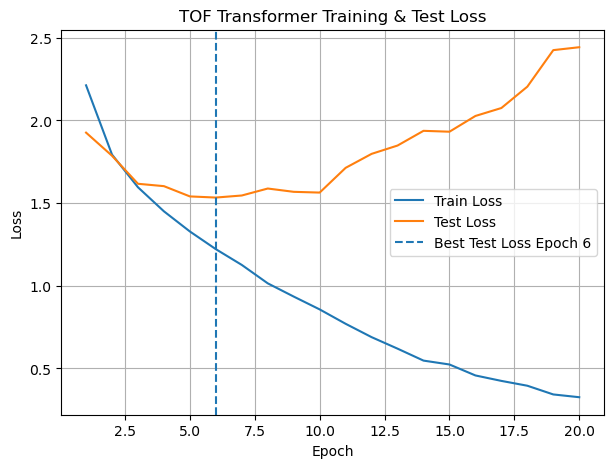

Saved: E:\A1 final\plots\tof_transformer\loss_curve.png


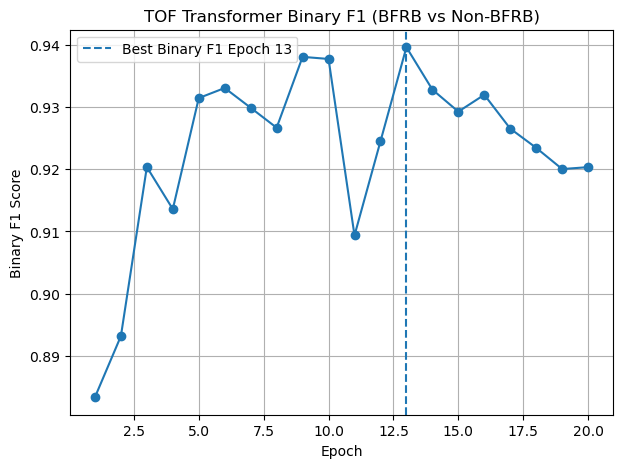

Saved: E:\A1 final\plots\tof_transformer\binary_f1_curve.png


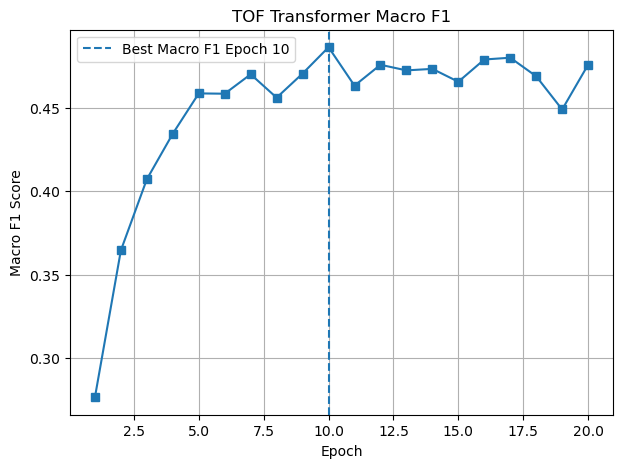

Saved: E:\A1 final\plots\tof_transformer\macro_f1_curve.png


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

PLOTS_DIR = REPO_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TOF_PLOT_DIR = PLOTS_DIR / "tof_transformer"
TOF_PLOT_DIR.mkdir(parents=True, exist_ok=True)

epochs = range(1, len(train_losses) + 1)

best_loss_epoch = int(np.argmin(test_losses)) + 1
best_bin_epoch = int(np.argmax(test_f1_bin_list)) + 1
best_macro_epoch = int(np.argmax(test_f1_macro9_list)) + 1

# =========================
# Plot 1: Training / Test Loss
# =========================
plt.figure(figsize=(7, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.axvline(best_loss_epoch, linestyle="--", label=f"Best Test Loss Epoch {best_loss_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TOF Transformer Training & Test Loss")
plt.legend()
plt.grid(True)

loss_path = TOF_PLOT_DIR / "loss_curve.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)

# =========================
# Plot 2: Binary F1 Curve
# =========================
plt.figure(figsize=(7, 5))
plt.plot(epochs, test_f1_bin_list, marker="o")
plt.axvline(best_bin_epoch, linestyle="--", label=f"Best Binary F1 Epoch {best_bin_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Binary F1 Score")
plt.title("TOF Transformer Binary F1 (BFRB vs Non-BFRB)")
plt.legend()
plt.grid(True)

binf1_path = TOF_PLOT_DIR / "binary_f1_curve.png"
plt.savefig(binf1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", binf1_path)

# =========================
# Plot 3: Macro F1 Curve
# =========================
plt.figure(figsize=(7, 5))
plt.plot(epochs, test_f1_macro9_list, marker="s")
plt.axvline(best_macro_epoch, linestyle="--", label=f"Best Macro F1 Epoch {best_macro_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")
plt.title("TOF Transformer Macro F1")
plt.legend()
plt.grid(True)

macro_path = TOF_PLOT_DIR / "macro_f1_curve.png"
plt.savefig(macro_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", macro_path)

1. It builds a summary dictionary containing the best epoch and the corresponding accuracy, macro F1, and binary F1 metrics.
2. It saves the summary as a JSON file and prints the output paths and final metrics for confirmation.

In [9]:
import json
import numpy as np
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start_path: Path):
    cur = start_path
    for _ in range(10):
        if (cur / ".git").exists() or (cur / "data").exists():
            return cur
        cur = cur.parent
    return start_path

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

ART_DIR = REPO_ROOT / "artifacts" / "tof_transformer"
SUMMARY_DIR = REPO_ROOT / "results" / "Model7_Training"

ART_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

best_idx = int(np.argmax(test_f1_macro9_list))

summary = {
    "best_epoch": best_idx + 1,
    "final_metrics": {
        "acc": float(test_acc_list[best_idx]),
        "macroF1": float(test_f1_macro9_list[best_idx]),
        "binaryF1": float(test_f1_bin_list[best_idx])
    }
}

print("Saved everything to:", ART_DIR)

summary_path = SUMMARY_DIR / "model7_training_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)
print("Final metrics:", summary["final_metrics"])

Saved everything to: E:\A1 final\artifacts\tof_transformer
Saved: E:\A1 final\results\Model7_Training\model7_training_summary.json
Final metrics: {'acc': 0.4812768569674647, 'macroF1': 0.4861046608101955, 'binaryF1': 0.9377431906614787}
